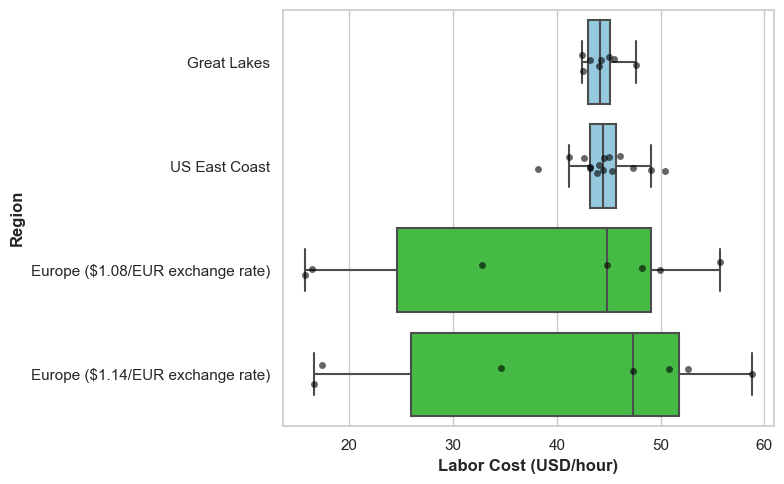

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_csv('data/labor_cost_data.csv', sep=None, engine='python')
df.columns = df.columns.str.strip()

# Drop missing values and exclude US Average
df = df.dropna(subset=['final_number_usd'])
df = df[df['category'].str.strip().str.lower() != 'us average']

# Identify unique categories
categories = df['category'].unique()

# Create a color palette: limegreen for Europe, skyblue for others
palette = {}
for cat in categories:
    if 'europe' in cat.lower():
        palette[cat] = 'limegreen'
    else:
        palette[cat] = 'skyblue'

# Set plot style
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(8, 5))
ax = sns.boxplot(y="category", x="final_number_usd", data=df,
                 palette=palette, fliersize=0)

# Overlay scatter plot for individual values
sns.stripplot(y="category", x="final_number_usd", data=df,
              color='black', size=5, jitter=0.1, alpha=0.6)

# Labels and formatting
plt.xlabel("Labor Cost (USD/hour)", fontweight="bold")
plt.ylabel("Region", fontweight="bold")
plt.tight_layout()
plt.savefig("Figures/labor_cost_by_region.png", dpi=300, bbox_inches="tight")
plt.show()
